In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import collections

emo_words= ['depressed','alarmed','aroused','pleased','serene','astonished',
            'miserable','content','excited','angry','tired','bored',
            'afraid','delighted','satisfied','calm','glad','distressed',
            'annoyed','droopy','gloomy','sleepy','frustrated','amused']

emo_categories = [3,2,1,4,4,1,
                  3,4,1,2,3,3,
                  2,1,4,4,1,2,
                  2,3,3,4,2,1]
# emo_color = ['tab:pink','tab:red','tab:blue','tab:green']
# emo_labels = ['+valence +arousal','-valence +arousal','-valence -arousal','+valence -arousal']

# change the categories to counterclockwise from the top right, 4 to 2, 2 to 4
emo_categories = [4 if c == 2 else 2 if c == 4 else c for c in emo_categories]
emo_color = ['tab:pink','tab:green','tab:blue','tab:red']
emo_labels = ['+valence +arousal','+valence -arousal','-valence -arousal','-valence +arousal']

beha_resp = pd.read_excel('behavior_resp.xlsx', index_col=0)
emo_ratings = collections.defaultdict(list)

 # for each row, extract the number of the rating for each emotion word
for sub in range(4):
    for w, word in enumerate(emo_words):
        valence = beha_resp.iloc[sub, 2*w+1]
        if valence[0] == '-':
            valence = int(valence[:2])
        else:
            valence = int(valence[0])
        arousal = beha_resp.iloc[sub, 2*w+2]
        if arousal[0] == '-':
            arousal = int(arousal[:2])
        else:
            arousal = int(arousal[0])
        emo_ratings[word].append((valence, arousal))

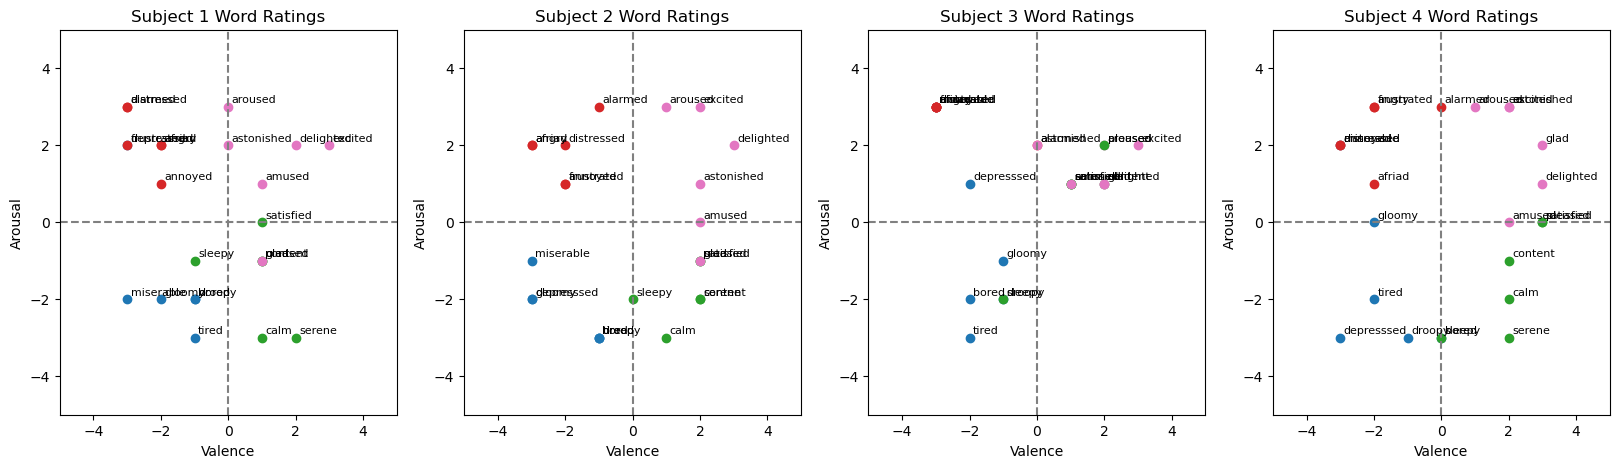

In [51]:
fig, ax = plt.subplots(1,4, figsize=(20, 5))
for sub in range(4):
    for w, word in enumerate(emo_words):
        valence, arousal = emo_ratings[word][sub]
        ax[sub].scatter(valence, arousal,c=emo_color[emo_categories[w]-1], label=emo_labels[emo_categories[w]-1])
        ax[sub].text(valence+0.1, arousal+0.1, word, fontsize=8)
    ax[sub].axhline(0, color='gray', linestyle='--')
    ax[sub].axvline(0, color='gray', linestyle='--')
    ax[sub].set_xlim(-5, 5)
    ax[sub].set_ylim(-5, 5)
    ax[sub].set_xlabel('Valence')
    ax[sub].set_ylabel('Arousal')
    ax[sub].set_title(f'Subject {sub+1} Word Ratings')


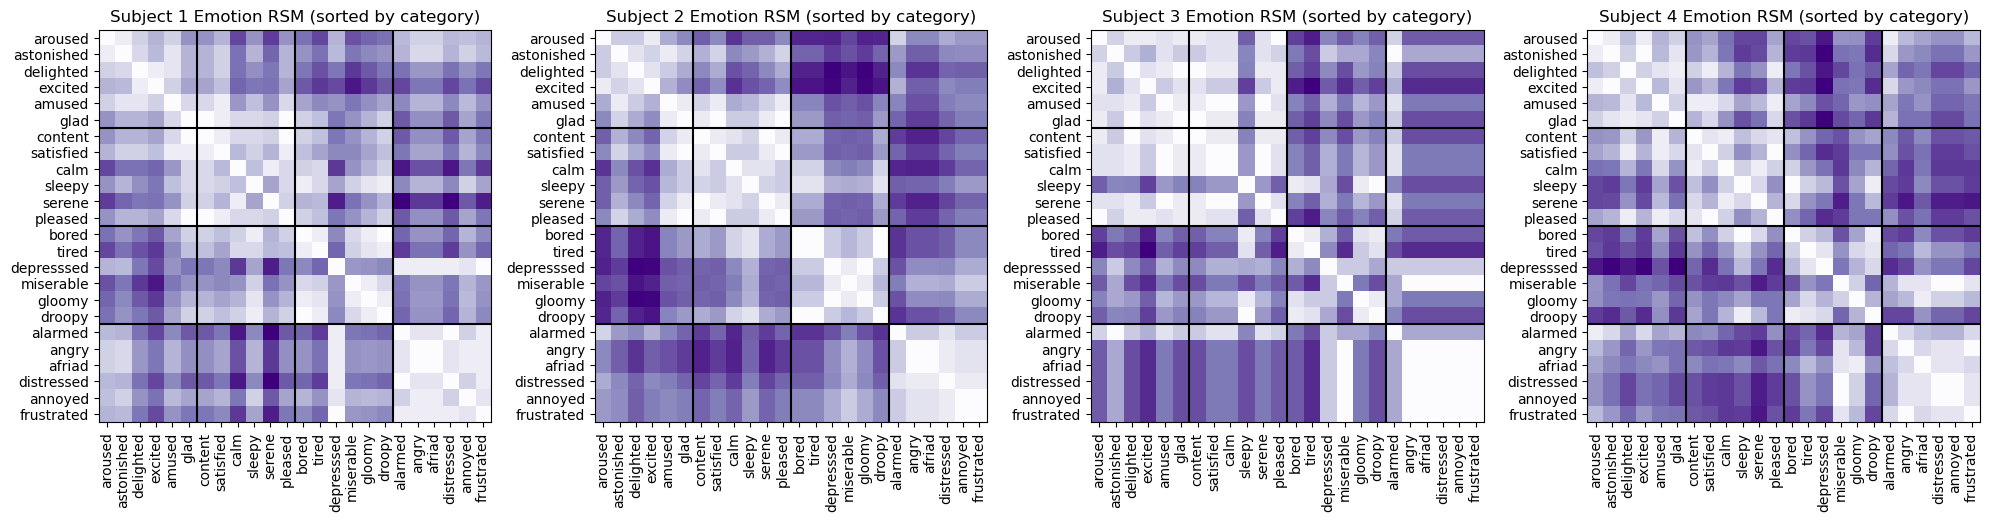

In [52]:
fig, ax = plt.subplots(1,4, figsize=(20, 5))

# sorting index by emotion category
sort_idx = np.argsort(emo_categories)

emo_words_sorted = [emo_words[i] for i in sort_idx]
emo_cat_sorted = [emo_categories[i] for i in sort_idx]


for sub in range(4):

    # build matrix in sorted order
    n = len(emo_words)
    RSM = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            wi = emo_words_sorted[i]
            wj = emo_words_sorted[j]

            val_i, aro_i = emo_ratings[wi][sub]
            val_j, aro_j = emo_ratings[wj][sub]

            RSM[i, j] = np.sqrt((val_i - val_j)**2 + (aro_i - aro_j)**2)

    ax[sub].imshow(RSM, cmap='Purples')
    ax[sub].set_xticks(range(n))
    ax[sub].set_yticks(range(n))
    ax[sub].set_xticklabels(emo_words_sorted, rotation=90)
    ax[sub].set_yticklabels(emo_words_sorted)

    # draw block boundaries
    cat_changes = np.where(np.diff(emo_cat_sorted))[0] + 1
    for b in cat_changes:
        ax[sub].axhline(b - 0.5, color='black')
        ax[sub].axvline(b - 0.5, color='black')

    ax[sub].set_title(f'Subject {sub+1} Emotion RSM (sorted by category)')
plt.tight_layout()
